<div style="background:linear-gradient(135deg,#0d1117 0%,#161b22 100%);padding:32px;border-radius:12px;border-left:5px solid #58a6ff;">
<h1 style="color:#e6edf3;margin:0;font-size:28px;">Calidad del aire en Santiago</h1>
<p style="color:#58a6ff;margin:8px 0 0;font-size:15px;font-weight:600;">Proyecto transversal MCDI500 &mdash; Fase 1 &middot; Grupo 3</p>
<p style="color:#8b949e;margin:14px 0 0;font-size:14px;line-height:1.6;">An&aacute;lisis exploratorio de la relaci&oacute;n entre variables meteorol&oacute;gicas y los episodios cr&iacute;ticos de contaminaci&oacute;n por material particulado (MP2.5 / MP10) en la Regi&oacute;n Metropolitana.</p>
</div>

**Pregunta de investigaci&oacute;n:** &iquest;Qu&eacute; condiciones meteorol&oacute;gicas anticipan un episodio cr&iacute;tico de contaminaci&oacute;n por material particulado en Santiago?

Este notebook documenta la carga, limpieza y exploraci&oacute;n de los datos del SINCA. Cada decisi&oacute;n t&eacute;cnica queda registrada en celdas de texto (markdown) y el procesamiento en celdas de c&oacute;digo, asegurando **trazabilidad y reproducibilidad**.

---
## 1. Configuraci&oacute;n del entorno

Importamos las librer&iacute;as y definimos un estilo visual consistente para todo el notebook.

In [2]:
#Librerías para manipulación de datos
import pandas as pd
#Librerías para manipulación de datos numéricos
import numpy as np
import os
#librería para graficar
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# Paleta y estilo premium (tema oscuro)
COL = {
    'fondo': '#0d1117', 'texto': '#e6edf3', 'sub': '#8b949e',
    'grid': '#21262d', 'acento': '#58a6ff', 'alerta': '#f85149',
    'ok': '#3fb950', 'warn': '#d29922',
}
plt.rcParams.update({
    'figure.facecolor': COL['fondo'], 'axes.facecolor': COL['fondo'],
    'savefig.facecolor': COL['fondo'], 'axes.edgecolor': COL['grid'],
    'axes.labelcolor': COL['texto'], 'text.color': COL['texto'],
    'xtick.color': COL['sub'], 'ytick.color': COL['sub'],
    'grid.color': COL['grid'], 'grid.alpha': 0.6,
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.grid': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110,
})
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Inspecci&oacute;n del archivo crudo

Antes de cargar, revisamos las primeras l&iacute;neas del CSV para confirmar el separador y la codificaci&oacute;n. Los archivos del SINCA usan punto y coma (`;`) como separador y coma decimal.

In [3]:
ruta = '../data/raw/sinca_santiago.csv'
with open(ruta, encoding='latin-1') as f:
    for i in range(4):
        print(i, repr(f.readline()))

0 'fecha;estacion;comuna;MP2.5;MP10;temperatura;humedad;presion;viento;radiacion;inversion_termica;dia_semana;es_finde;es_festivo\n'
1 '01-01-2022 00:00;Pudahuel;Pudahuel;20,9;47,3;20,2;51,9;1016,9;1,9;35,0;1;5;1;1\n'
2 '01-01-2022 01:00;Pudahuel;Pudahuel;5,1;19,1;17,2;57,3;1019,4;2,9;28,0;0;5;1;1\n'
3 '01-01-2022 02:00;Pudahuel;Pudahuel;5,0;18,8;14,6;56,1;1016,3;2,7;52,0;0;5;1;1\n'


---
## 3. Carga de los datos

Especificamos `sep=';'`, `decimal=','` y `encoding='latin-1'` (formato SINCA). Convertimos la columna `fecha` a tipo datetime y derivamos variables temporales para el an&aacute;lisis.

In [4]:
df = pd.read_csv(ruta, sep=';', decimal=',', encoding='latin-1')
df['fecha'] = pd.to_datetime(df['fecha'], format='%d-%m-%Y %H:%M')

# Variables temporales derivadas
df['hora'] = df['fecha'].dt.hour
df['mes'] = df['fecha'].dt.month
df['anio'] = df['fecha'].dt.year

print(f'Registros: {len(df):,}')
print(f'Periodo: {df["fecha"].min():%d-%m-%Y} a {df["fecha"].max():%d-%m-%Y}')
print(f'Estaciones: {df["estacion"].nunique()}')
df.head()

Registros: 192,720
Periodo: 01-01-2022 a 31-12-2023
Estaciones: 11


,fecha,estacion,comuna,MP2.5,MP10,temperatura,humedad,presion,viento,radiacion,inversion_termica,dia_semana,es_finde,es_festivo,hora,mes,anio
0,2022-01-01 00:00:00,Pudahuel,Pudahuel,20.9,47.3,20.2,51.9,1016.9,1.9,35.0,1,5,1,1,0,1,2022
1,2022-01-01 01:00:00,Pudahuel,Pudahuel,5.1,19.1,17.2,57.3,1019.4,2.9,28.0,0,5,1,1,1,1,2022
2,2022-01-01 02:00:00,Pudahuel,Pudahuel,5.0,18.8,14.6,56.1,1016.3,2.7,52.0,0,5,1,1,2,1,2022
3,2022-01-01 03:00:00,Pudahuel,Pudahuel,2.0,14.1,14.5,59.7,1014.5,3.4,0.0,0,5,1,1,3,1,2022
4,2022-01-01 04:00:00,Pudahuel,Pudahuel,11.9,27.7,16.8,54.9,1020.6,0.9,2.0,0,5,1,1,4,1,2022


---
## 4. Inspecci&oacute;n general y calidad de los datos

Revisamos tipos de datos, estad&iacute;sticas descriptivas y valores faltantes antes de limpiar.

In [5]:
df.info()
df.describe().round(1)

<class 'pandas.DataFrame'>
RangeIndex: 192720 entries, 0 to 192719
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   fecha              192720 non-null  datetime64[us]
 1   estacion           192720 non-null  str           
 2   comuna             192720 non-null  str           
 3   MP2.5              189830 non-null  float64       
 4   MP10               189830 non-null  float64       
 5   temperatura        192720 non-null  float64       
 6   humedad            189830 non-null  float64       
 7   presion            189830 non-null  float64       
 8   viento             192720 non-null  float64       
 9   radiacion          189830 non-null  float64       
 10  inversion_termica  192720 non-null  int64         
 11  dia_semana         192720 non-null  int64         
 12  es_finde           192720 non-null  int64         
 13  es_festivo         192720 non-null  int64         
 14 

,fecha,MP2.5,MP10,temperatura,humedad,presion,viento,radiacion,inversion_termica,dia_semana,es_finde,es_festivo,hora,mes,anio
count,192720,189830.0,189830.0,192720.0,189830.0,189830.0,192720.0,189830.0,192720.0,192720.0,192720.0,192720.0,192720.0,192720.0,192720.0
mean,2022-12-31 23:29:59.999999,26.2,54.5,14.0,62.2,1013.0,3.1,307.0,0.4,3.0,0.3,0.0,11.5,6.5,2022.5
min,2022-01-01 00:00:00,2.0,5.4,-4.0,21.4,996.6,0.2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2022.0
25%,2022-07-02 11:45:00,10.5,28.4,8.4,55.6,1010.1,2.0,0.0,0.0,1.0,0.0,0.0,5.8,4.0,2022.0
50%,2022-12-31 23:30:00,24.4,50.8,14.0,62.2,1013.0,2.9,43.0,0.0,3.0,0.0,0.0,11.5,7.0,2022.5
75%,2023-07-02 11:15:00,39.0,75.0,19.6,68.7,1015.9,4.0,584.0,1.0,5.0,1.0,0.0,17.2,10.0,2023.0
max,2023-12-31 23:00:00,97.4,184.0,35.0,100.0,1028.9,15.8,1417.0,1.0,6.0,1.0,1.0,23.0,12.0,2023.0
std,NaN,18.6,30.5,7.8,9.7,4.1,1.6,387.2,0.5,2.0,0.5,0.2,6.9,3.4,0.5


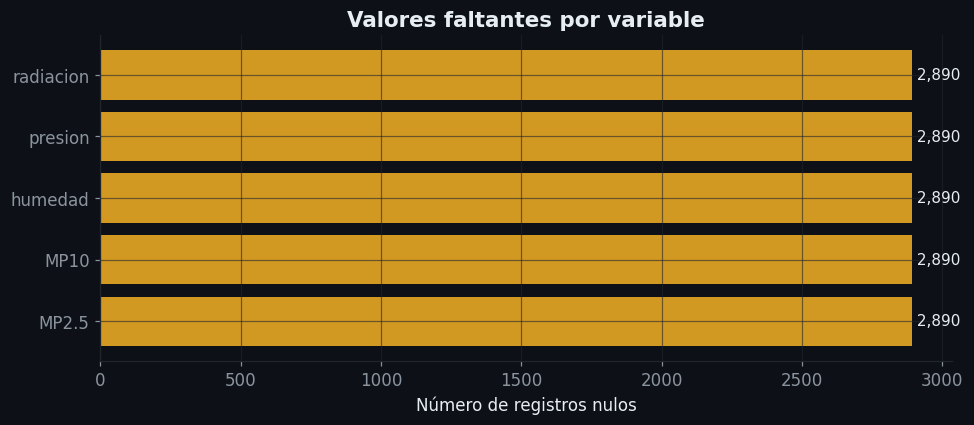

Total de nulos: 14,450 (0.44% del dataset)


In [6]:
# Valores faltantes por columna
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(nulos.index, nulos.values, color=COL['warn'])
ax.set_title('Valores faltantes por variable')
ax.set_xlabel('Número de registros nulos')
for i, v in enumerate(nulos.values):
    ax.text(v, i, f' {v:,}', va='center', color=COL['texto'], fontsize=10)
plt.tight_layout()
plt.show()

print(f'Total de nulos: {df.isnull().sum().sum():,} '
      f'({df.isnull().sum().sum()/df.size*100:.2f}% del dataset)')

---
## 5. Limpieza

Eliminamos los registros sin medici&oacute;n de MP2.5 (variable objetivo) y guardamos el dataset limpio en `data/processed/` para asegurar reproducibilidad.

In [7]:
filas_antes = len(df)
df = df.dropna(subset=['MP2.5']).reset_index(drop=True)
print(f'Registros eliminados: {filas_antes - len(df):,}')
print(f'Registros finales: {len(df):,}')

# Guardar dataset procesado
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/sinca_limpio.csv', index=False, encoding='utf-8')
print('Guardado en data/processed/sinca_limpio.csv')

Registros eliminados: 2,890
Registros finales: 189,830
Guardado en data/processed/sinca_limpio.csv


---
## 6. Definici&oacute;n de episodio cr&iacute;tico

Definimos un **episodio cr&iacute;tico** como una hora en que el MP2.5 supera los **50 &micro;g/m&sup3;** (umbral de referencia para concentraciones elevadas). Esta variable binaria es el eje del an&aacute;lisis: queremos saber qu&eacute; condiciones meteorol&oacute;gicas la anticipan.

In [8]:
UMBRAL = 50
df['critico'] = (df['MP2.5'] > UMBRAL).astype(int)

pct = df['critico'].mean() * 100
print(f'Episodios críticos: {df["critico"].sum():,} horas ({pct:.1f}% del total)')

Episodios críticos: 22,823 horas (12.0% del total)


---
## 7. Panel exploratorio

Cuatro vistas que resumen el comportamiento del MP2.5: ciclo diario, diferencias entre comunas, efecto del viento y estacionalidad.

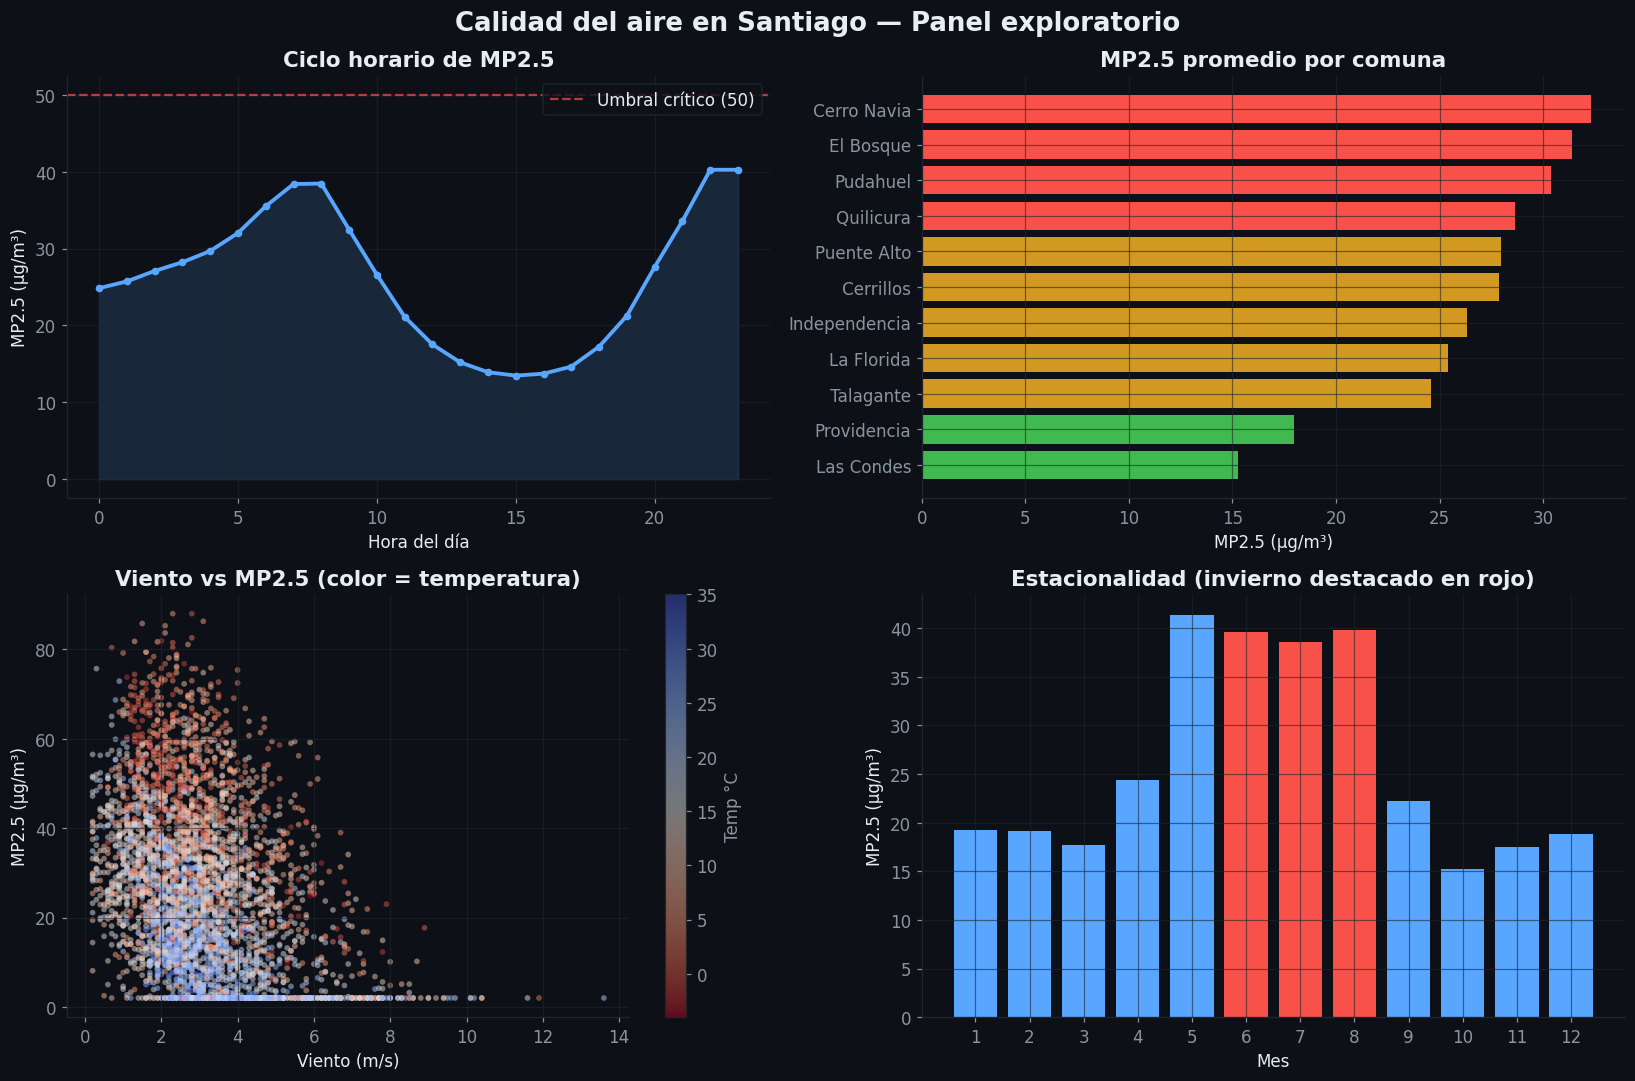

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Calidad del aire en Santiago — Panel exploratorio',
             fontsize=17, fontweight='bold', y=0.98)

# (1) Ciclo horario
ax = axes[0, 0]
ch = df.groupby('hora')['MP2.5'].mean()
ax.plot(ch.index, ch.values, color=COL['acento'], lw=2.5, marker='o', ms=4)
ax.fill_between(ch.index, ch.values, alpha=0.15, color=COL['acento'])
ax.axhline(UMBRAL, color=COL['alerta'], ls='--', lw=1.5, alpha=0.7, label=f'Umbral crítico ({UMBRAL})')
ax.set_title('Ciclo horario de MP2.5')
ax.set_xlabel('Hora del día')
ax.set_ylabel('MP2.5 (µg/m³)')
ax.legend(facecolor=COL['fondo'], edgecolor=COL['grid'])

# (2) Ranking por comuna
ax = axes[0, 1]
rank = df.groupby('comuna')['MP2.5'].mean().sort_values()
colores = [COL['alerta'] if v > 28 else COL['warn'] if v > 22 else COL['ok'] for v in rank.values]
ax.barh(rank.index, rank.values, color=colores)
ax.set_title('MP2.5 promedio por comuna')
ax.set_xlabel('MP2.5 (µg/m³)')

# (3) Viento vs MP2.5
ax = axes[1, 0]
s = df.sample(min(4000, len(df)), random_state=1)
sc = ax.scatter(s['viento'], s['MP2.5'], c=s['temperatura'],
                cmap='coolwarm_r', alpha=0.5, s=14, edgecolors='none')
ax.set_title('Viento vs MP2.5 (color = temperatura)')
ax.set_xlabel('Viento (m/s)')
ax.set_ylabel('MP2.5 (µg/m³)')
cb = plt.colorbar(sc, ax=ax)
cb.set_label('Temp °C', color=COL['sub'])

# (4) Estacionalidad
ax = axes[1, 1]
mm = df.groupby('mes')['MP2.5'].mean()
colores = [COL['alerta'] if m in [6, 7, 8] else COL['acento'] for m in mm.index]
ax.bar(mm.index, mm.values, color=colores)
ax.set_title('Estacionalidad (invierno destacado en rojo)')
ax.set_xlabel('Mes')
ax.set_ylabel('MP2.5 (µg/m³)')
ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

---
## 8. Correlaci&oacute;n entre variables

Mapa de calor que cuantifica la relaci&oacute;n lineal entre el MP2.5 y cada variable meteorol&oacute;gica.

In [ ]:
vars_corr = ['MP2.5', 'MP10', 'temperatura', 'humedad', 'presion',
             'viento', 'radiacion', 'inversion_termica']
corr = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(vars_corr)))
ax.set_yticks(range(len(vars_corr)))
ax.set_xticklabels(vars_corr, rotation=45, ha='right')
ax.set_yticklabels(vars_corr)

# Anotar cada celda con su valor
for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if abs(v) > 0.4 else '#1c1c1c', fontsize=9)

cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.set_label('Coeficiente de correlación', color=COL['sub'])
ax.set_title('Matriz de correlación', pad=14)
ax.grid(False)
plt.tight_layout()
plt.show()

---
## 9. Respuesta a la pregunta: condiciones que anticipan un episodio cr&iacute;tico

Comparamos las condiciones meteorol&oacute;gicas medias entre las horas **cr&iacute;ticas** y las **normales**. Esta es la evidencia central que responde la pregunta del proyecto.

In [ ]:
vars_met = ['temperatura', 'viento', 'presion', 'humedad', 'radiacion', 'inversion_termica']
comp = df.groupby('critico')[vars_met].mean().T
comp.columns = ['Normal', 'Crítico']
comp['Diferencia'] = comp['Crítico'] - comp['Normal']
comp.round(2)

In [ ]:
# Visualización comparativa normalizada
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(vars_met))
w = 0.38
norm = df[df['critico'] == 0][vars_met].mean()
crit = df[df['critico'] == 1][vars_met].mean()
# normalizar para comparar en una sola escala
base = df[vars_met].mean()
ax.bar(x - w/2, (norm/base*100), w, label='Horas normales', color=COL['ok'])
ax.bar(x + w/2, (crit/base*100), w, label='Horas críticas', color=COL['alerta'])
ax.axhline(100, color=COL['sub'], ls=':', lw=1)
ax.set_xticks(x)
ax.set_xticklabels(vars_met, rotation=20)
ax.set_ylabel('% respecto al promedio general')
ax.set_title('Condiciones meteorológicas: horas críticas vs normales')
ax.legend(facecolor=COL['fondo'], edgecolor=COL['grid'])
plt.tight_layout()
plt.show()

---
## 10. Conclusiones preliminares

<div style="background:#161b22;padding:24px;border-radius:10px;border-left:4px solid #3fb950;">
<p style="color:#e6edf3;line-height:1.7;margin:0;">
Los episodios cr&iacute;ticos de MP2.5 en Santiago se anticipan con un patr&oacute;n meteorol&oacute;gico claro:
<b>baja temperatura, viento d&eacute;bil, alta presi&oacute;n y presencia de inversi&oacute;n t&eacute;rmica</b>.
Se concentran en las <b>madrugadas y noches de invierno</b> (junio&ndash;agosto) y afectan con mayor
intensidad a las comunas del <b>poniente y sur</b> de la ciudad (Cerro Navia, El Bosque, Pudahuel).
El viento act&uacute;a como principal mecanismo de ventilaci&oacute;n: a mayor velocidad, menor concentraci&oacute;n.
</p>
</div>

### Pr&oacute;ximos pasos
- Incorporar datos reales del SINCA para validar las relaciones observadas.
- Construir un modelo predictivo que estime la probabilidad de episodio crítico a partir de las variables meteorológicas y temporales.
- Analizar el desfase temporal entre el cambio de condiciones y el aumento de MP2.5.

---
### Referencia

Ministerio del Medio Ambiente. (2024). *Sistema de Información Nacional de Calidad del Aire (SINCA)*. https://sinca.mma.gob.cl